### Imports

In [6]:
import numpy as np
import pandas as pd
import sklearn as skl
import skimage as ski
from tqdm import tqdm, trange
import matplotlib.pyplot as plt

### Constant and Variable instatiation

In [ ]:
PALLET_DIMS = (1000, 1400, 1400)  # length, width, height (X, Y, Z, respectively) in mm
ML_OBSERVATION_SCALE_FACTOR = 10

In [ ]:
class Pallet:
    def __init__(self, dims=PALLET_DIMS):                                   # Initialize pallet with given dimensions
        # unpack pallet dimensions
        self.size_x, self.size_y, self.size_z = dims
        # Initialize list to store boxes placed on the pallet
        self.boxes = []
        # Initialize heightmap to track box heights at each (x, y) position
        self.heightmap = np.zeros((self.size_x, self.size_y), dtype=np.int32)

    def reset(self):                                                        # Emtpy the pallet
        # Clear the list of boxes
        self.boxes = []
        # Reset the heightmap to all zeros
        self.heightmap = np.zeros((self.size_x, self.size_y))

    def get_max_height(self):                                               # max height of boxes on the pallet, value to optimize for
        return np.max(self.heightmap)
    
    def get_max_height_in_area(self, x, y, dx, dy):                         # get the maximum height in a rectangular area of the heightmap
        # Ensure we don't go out of bounds
        x_end = min(x + dx, self.size_x)                                          
        y_end = min(y + dy, self.size_y)

        # Specify the rectangle being checked
        region = self.heightmap[x:x_end, y:y_end]

        # Return -1 (fail) if the region is of size 0 or smaller
        if region.size <= 0:
            return -1
        
        # Otherwise, return the maximum height in the region
        return np.max(region)
    
    def get_in_bounds_status(self, x, y, z):                                # Check if the given (x, y, z) position is within the pallet boundaries
        return (x <= self.size_x) and (y <= self.size_y) and (z <= self.size_z)
    
    def place_box(self, box_dims, x, y):                                    # attempt to place a box of given dimensions at (x, y) position on the pallet
        # Unpack box dimensions
        dx, dy, dz = box_dims

        # Make sure x and y are ints so we don't get partial millimeters from the model
        x = int(x)
        y = int(y)

        # Get the height the bottom of the box will be
        z = self.get_max_height_in_area(x, y, dx, dy)

        # Check if the box fits within the pallet boundaries, or return False
        if not self.get_in_bounds_status(x+dx, y+dy, z+dz):
            return False

        # Place the box by updating the heightmap
        self.heightmap[x:x+dx, y:y+dy] = z + dz

        # Store the box's position and dimensions
        self.boxes.append({
            'x': x, 'y': y, 'z': z, 'dx': dx, 'dy': dy, 'dz': dz
        })

        # Return True to indicate successful placement
        return True
    
    def visualize_heightmap(self):                                          # Visualize the heightmap
        plt.imshow(self.heightmap.T, origin='lower', cmap='viridis', extent=[0, self.size_x, 0, self.size_y])
        plt.colorbar(label='Height (mm)')
        plt.title('Pallet Heightmap')
        plt.xlabel('X (mm)')
        plt.ylabel('Y (mm)')
        plt.show()

    def visualize_boxes(self):                                              # Visualize the 3d boxes on the pallet using matplotlib
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')

        for box in self.boxes:
            # Create a 3D bar for each box
            ax.bar3d(box['x'], box['y'], box['z'], box['dx'], box['dy'], box['dz'], alpha=0.7)

        ax.set_xlabel('X (mm)')
        ax.set_ylabel('Y (mm)')
        ax.set_zlabel('Z (mm)')
        ax.set_title('Boxes on Pallet')
        plt.show()

    def get_observation(self, scale_factor=ML_OBSERVATION_SCALE_FACTOR):    # Get a scaled resolution view of the height map for RL
        # Use block_reduce from scikit-image to scale down heightmap, making sure to take the max so the model knows the top.
        observation = ski.measure.block_reduce(self.heightmap, block_size=(scale_factor, scale_factor), func=np.max)
        return observation

In [9]:
def place_random_boxes_on_pallet(pallet, num_boxes, box_size_range):         # Place a number of random boxes on the pallet
    for _ in range(num_boxes):
        # Generate random box dimensions within the specified range
        dx = np.random.randint(box_size_range[0], box_size_range[1])
        dy = np.random.randint(box_size_range[0], box_size_range[1])
        dz = np.random.randint(box_size_range[0], box_size_range[1])

        # Generate random (x, y) position for the box
        x = np.random.randint(0, pallet.size_x)
        y = np.random.randint(0, pallet.size_y)

        # Attempt to place the box on the pallet
        pallet.place_box((dx, dy, dz), x, y)

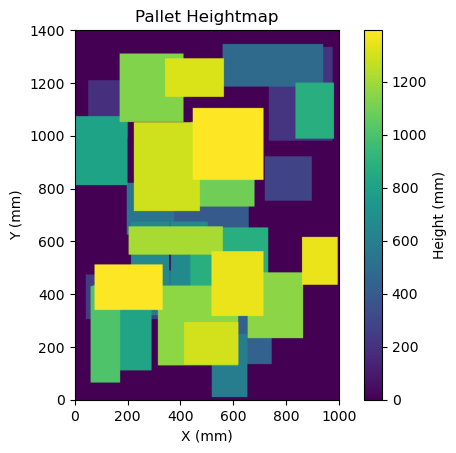

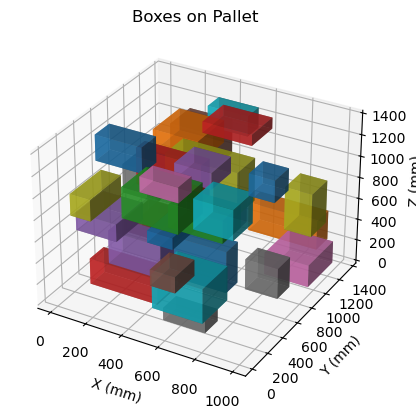

In [10]:
first = Pallet()
place_random_boxes_on_pallet(first, num_boxes=100, box_size_range=(100, 400))

first.visualize_heightmap()
first.visualize_boxes()